<a href="https://colab.research.google.com/github/Varsha7781/Deep-Learning/blob/main/Theory_assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2

Name : Varsharani Lad

PRN : 202301040104

GitHub:

**IMPORTS**

In [2]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f18d25a42a3073052bacb40221100183022aeb4ca0efca50ef5ba7f6563463af
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

import shap
from lime.lime_tabular import LimeTabularExplainer

import tensorflow as tf
from tensorflow.keras import layers, models
import cv2

sns.set_style("whitegrid")

**LOAD DATASET**

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**PREPROCESSING**

In [5]:
# Missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode categorical
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# Drop irrelevant columns
df.drop(['Name','Ticket','Cabin','PassengerId'], axis=1, inplace=True)

# Split features
X = df.drop('Survived', axis=1)
y = df['Survived']

# Scaling (extra marks)
scaler = StandardScaler()
X[['Age','Fare']] = scaler.fit_transform(X[['Age','Fare']])

/tmp/ipykernel_873/1369101207.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_873/1369101207.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

**DATA VISUALIZATION**

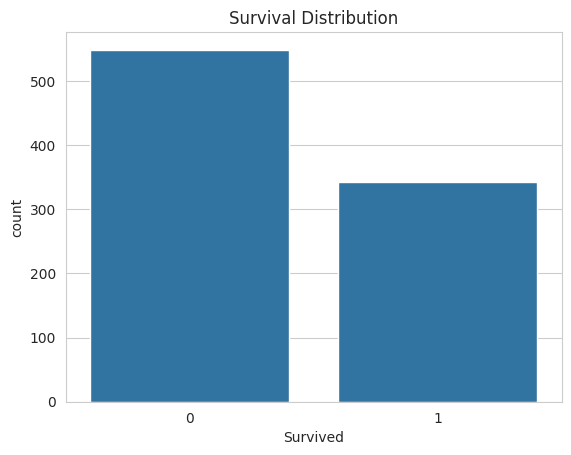

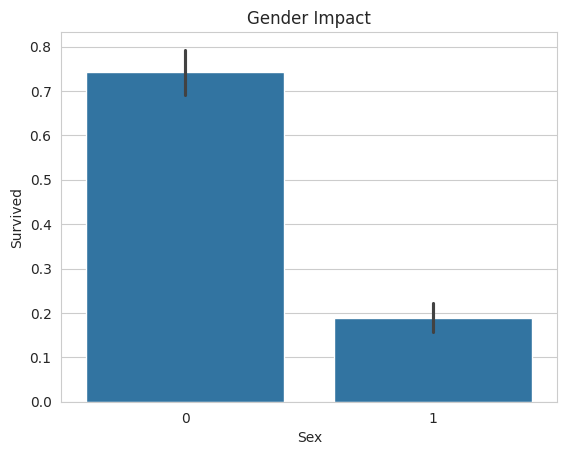

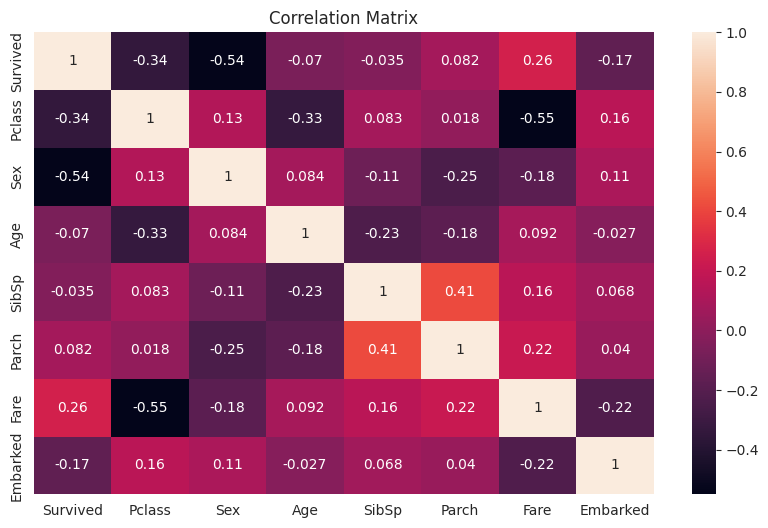

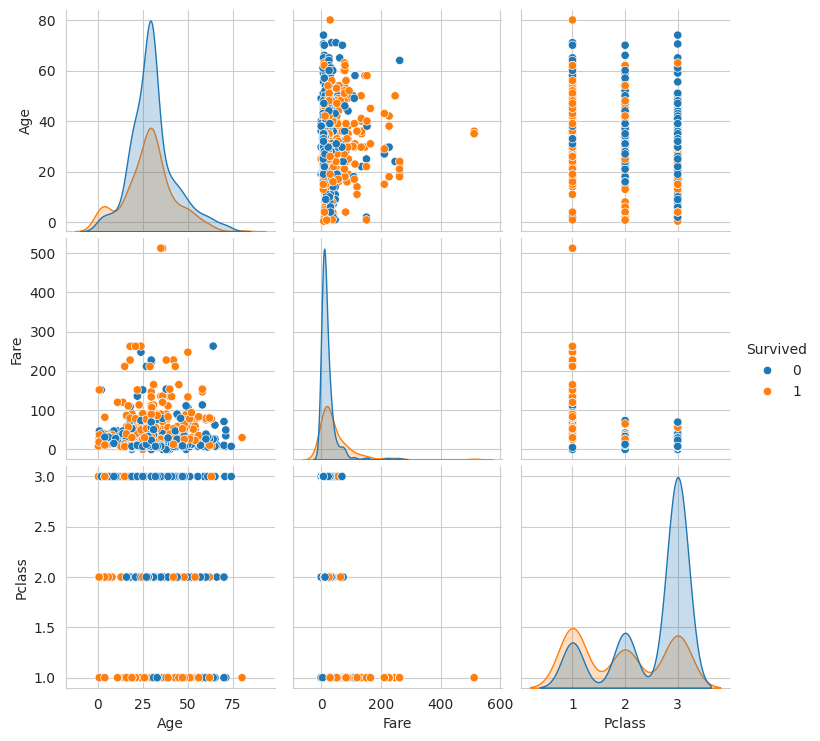

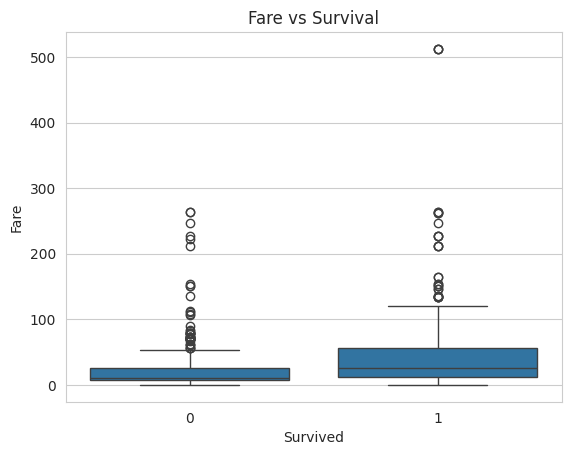

In [6]:
# Survival Distribution
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

# Gender vs Survival
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Gender Impact")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Pairplot (high scoring)
sns.pairplot(df[['Age','Fare','Pclass','Survived']], hue='Survived')
plt.show()

# Boxplot
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()

**TRAIN-TEST SPLIT**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**MODEL TRAINING**

In [8]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



**MODEL EVALUATION VISUALS**

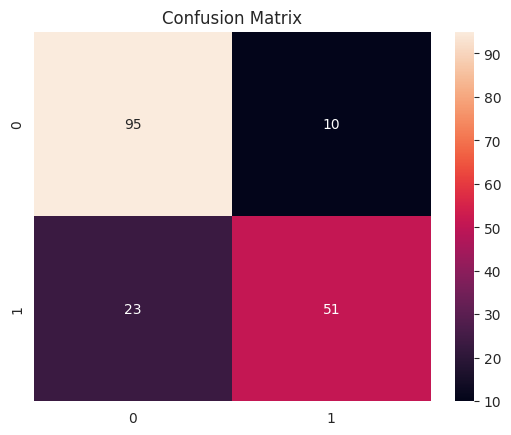

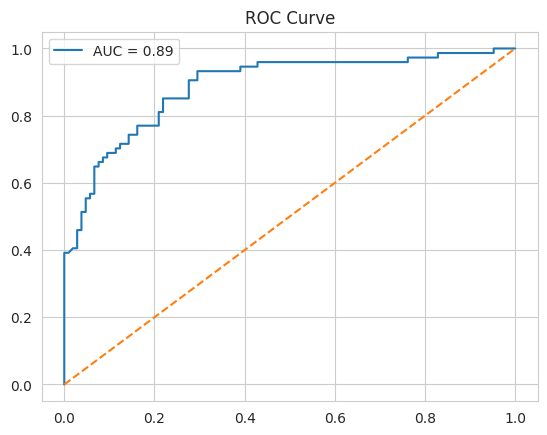

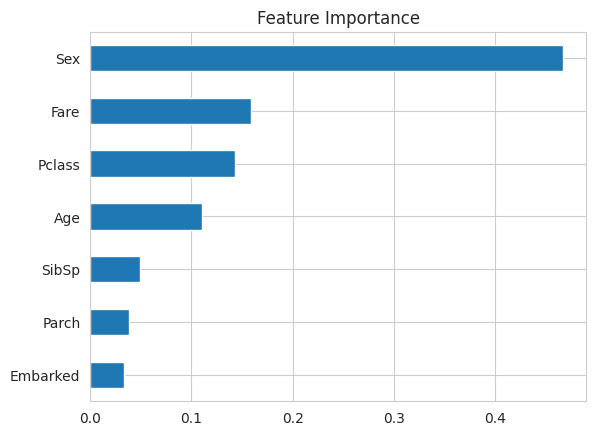

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve (extra marks)
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

**SHAP (GLOBAL + LOCAL)**

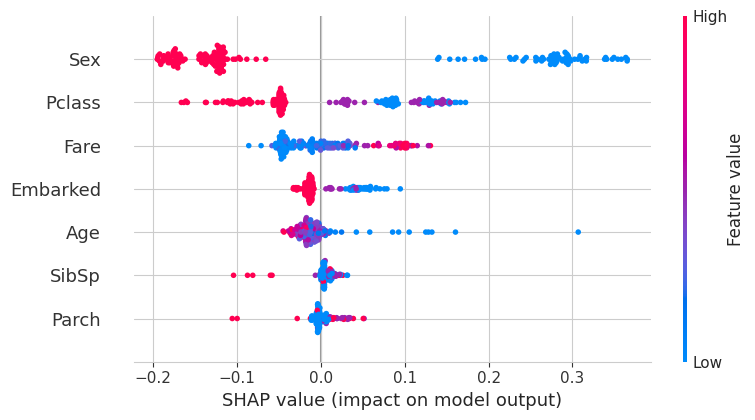

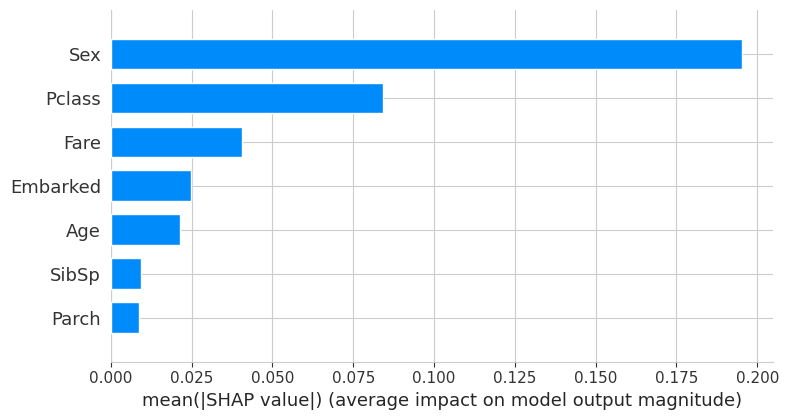

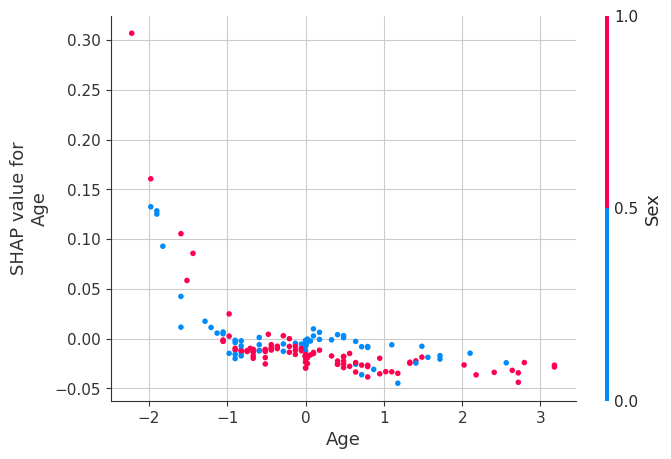

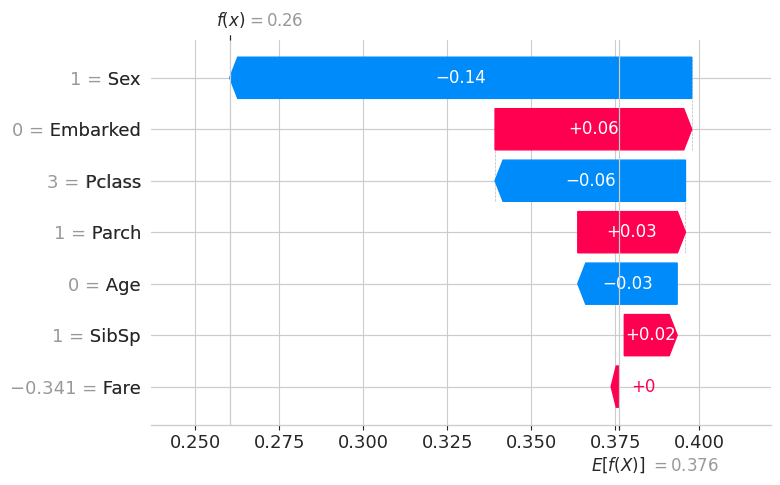

In [16]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Handle shape safely
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]

# Plots
shap.summary_plot(shap_vals, X_test)
shap.summary_plot(shap_vals, X_test, plot_type="bar")
shap.dependence_plot("Age", shap_vals, X_test)

# Force plot (FINAL FIX)
import shap

# Fix base value properly
base_value = explainer.expected_value

# If it's list → pick class 1
if isinstance(base_value, list) or isinstance(base_value, np.ndarray):
    base_value = base_value[1]

# If still array → take single value
if isinstance(base_value, np.ndarray):
    base_value = base_value.item()

# Create Explanation object
expl = shap.Explanation(
    values=shap_vals[0],
    base_values=base_value,
    data=X_test.iloc[0].values,
    feature_names=X_test.columns
)

# ✅ Waterfall plot (FINAL WORKING)
shap.plots.waterfall(expl)

**LIME (LOCAL EXPLANATION)**

In [17]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    class_names=['Not Survived','Survived'],
    mode='classification'
)

exp = explainer_lime.explain_instance(
    X_test.iloc[0].values,
    model.predict_proba
)

exp.show_in_notebook()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# **PART B: CNN + GRAD-CAM**

**LOAD MNIST**

In [18]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**BUILD CNN**

In [29]:
import tensorflow as tf
from tensorflow.keras import layers

inputs = tf.keras.Input(shape=(28,28,1))

x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)

outputs = layers.Dense(10, activation='softmax')(x)

model_cnn = tf.keras.Model(inputs, outputs)

In [30]:
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_cnn.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 33ms/step - accuracy: 0.9574 - loss: 0.1395 - val_accuracy: 0.9852 - val_loss: 0.0445
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9862 - loss: 0.0468 - val_accuracy: 0.9869 - val_loss: 0.0371
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9898 - loss: 0.0319 - val_accuracy: 0.9886 - val_loss: 0.0311


In [22]:
model_cnn.predict(x_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


array([[5.3725488e-12, 5.9133129e-11, 6.0563593e-08, 2.3116964e-08,
        2.1786282e-12, 5.8103099e-11, 2.0996037e-15, 9.9999976e-01,
        4.7530696e-10, 1.2334370e-07]], dtype=float32)

**GRAD-CAM FUNCTION**

In [31]:
def get_gradcam_heatmap(model, image, class_index):
    # Get last conv layer
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap.numpy()

In [27]:
model_cnn.build((None, 28, 28, 1))